In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [69]:
data_orig=pd.read_csv('AppML_ZTF_table.csv',index_col=0)
# remove nonsensical columns
# everything with jd makes no sense on its own - but relative timings do
# coordinates are probably not good either? tho galactic ones might be ok?
cols_to_drop=['objectId', 'decmean', 'decstd', 'ramean', 'rastd','tns_name','tns_type','host_name','dmdt_r_2','ncandgp_7', 'ncandgp_14','dmdt_g_2','htm16','ssnamenr','jdmax','jdmin','jd_g_minus_r','jdgmax','htm16']

# make new features based on combinations of previous features

# duration of light curve
data_orig['duration']=data_orig['jdmax']-data_orig['jdmin']

# difference in peak g and r mag 
data_orig['g_minus_r_max']=data_orig['maggmax']-data_orig['magrmax']
# difference in mean g and r mag
data_orig['g_minus_r_mean']=data_orig['maggmean']-data_orig['magrmean']
# drop VarStar and AGN classifications immediately
mask=(data_orig['classification']!='AGN')&(data_orig['classification']!='VS')
data_orig=data_orig[mask].reset_index(drop=True)
data=data_orig.drop(columns=cols_to_drop)
data


,glatmean,glonmean,gmag,dmdt_g,mag_g02,mag_g08,mag_g28,maggmax,maggmean,maggmin,...,dmdt_g_err,dmdt_r_err,z,classification,classificationReliability,distance,separationArcsec,duration,g_minus_r_max,g_minus_r_mean
0,-35.242562,213.676050,19.2207,-0.104339,19.2206,19.0303,18.1721,19.2207,17.6862,17.1446,...,0.007967,0.231327,0.0390,NT,1.0,170.768,0.309,27.023750,0.5509,-0.2066
1,88.734347,9.150914,19.4562,-0.021550,19.4471,19.3349,19.2059,19.5491,19.3299,19.0772,...,0.047270,0.082093,NaN,CV,1.0,0.000,0.636,25.853924,0.7280,0.7658
2,26.239936,196.535001,18.5962,NaN,18.5761,18.4154,18.3382,18.9187,17.9833,15.4142,...,NaN,NaN,NaN,CV,1.0,0.000,0.120,29.109479,0.6531,1.0634
3,11.192324,144.087607,20.4923,NaN,20.4872,20.3988,19.9312,20.4923,19.6848,19.1569,...,NaN,NaN,NaN,SN,2.0,0.000,0.500,29.103310,0.4273,0.3198
4,81.800603,315.678278,19.6440,0.084961,226905.0000,36.9120,21.3822,20.2372,19.6100,19.1907,...,-0.125825,-0.029304,NaN,NT,1.0,368.240,0.640,25.999097,0.5109,0.2866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,-40.516657,104.172897,19.9759,0.041084,19.9777,20.0506,19.5180,20.4286,17.8157,16.8336,...,0.033278,0.005672,0.0139,SN,2.0,61.640,10.710,214.636262,0.8230,0.4692
13316,45.179705,234.125040,19.3177,NaN,19.3177,19.3177,19.3177,19.3177,19.3177,19.3177,...,NaN,0.129790,NaN,NT,1.0,442.711,1.484,12.008113,-0.2865,0.0911
13317,47.456474,232.104407,19.2806,NaN,19.2806,19.2806,19.2806,19.2806,19.2806,19.2806,...,NaN,0.131565,NaN,SN,2.0,444.528,6.756,10.076563,-0.3316,-0.0402
13318,-4.446613,44.499667,19.5741,-0.962985,18.8469,17.7216,16.5062,19.5741,16.7950,15.1485,...,0.075493,0.028401,NaN,SN,2.0,0.000,7.025,29.994780,2.1955,-0.0155


In [70]:
from sklearn import cluster, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
# Remove non-numeric / metadata columns
X = data.drop(columns=["classification", "classificationReliability"])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Missing values per column
missing = X.isna().sum().sort_values(ascending=False)

# Percentage missing
missing_pct = 100 * X.isna().mean()

print(pd.DataFrame({
    "missing": missing,
    "pct": missing_pct
}).sort_values("pct", ascending=False))

                  missing        pct
z                    8436  63.333333
distance             3286  24.669670
dmdt_g_err           2885  21.659159
sgscore1             2492  18.708709
dmdt_r_err           2378  17.852853
srmag1               1281   9.617117
sgmag1               1281   9.617117
distpsnr1            1281   9.617117
dmdt_g                807   6.058559
g_minus_r             752   5.645646
g_minus_r_max         670   5.030030
g_minus_r_mean        670   5.030030
maggmin               618   4.639640
maggmax               618   4.639640
gmag                  618   4.639640
maggmean              618   4.639640
mag_g02               618   4.639640
mag_g08               618   4.639640
mag_g28               618   4.639640
separationArcsec      272   2.042042
dmdt_r                169   1.268769
rmag                   52   0.390390
magrmean               52   0.390390
magrmin                52   0.390390
mag_r08                52   0.390390
magrmax                52   0.390390
m

In [71]:
row_missing_pct = X.isna().mean(axis=1)

print(row_missing_pct.describe())

count    13320.000000
mean         0.069338
std          0.088667
min          0.000000
25%          0.029412
50%          0.029412
75%          0.088235
max          0.558824
dtype: float64


In [72]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = data.drop(columns=["classification", "classificationReliability"])

# Missingness indicators
X_missing = X.isna().astype(int).add_suffix("_missing")

# Median imputation
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Combine
X_combined = pd.concat([X_imputed, X_missing], axis=1)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_combined),
    columns=X_combined.columns,
    index=X_combined.index
)

In [73]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    #contamination=0.01,
    random_state=402
)

scores = iso.fit_predict(X_scaled)
probs=iso.score_samples(X_scaled)

data["anomaly"] = scores
data_orig['anomaly']=scores
data["anomaly_score"] = probs
data_orig['anomaly_score']=probs

In [74]:
anoms=data_orig[data_orig.anomaly==-1]
# drop duplicates
anoms=anoms.drop_duplicates(subset='objectId').reset_index(drop=True)
anoms=anoms.drop_duplicates(subset='tns_name').reset_index(drop=True)
anoms.tns_type.unique()

array([nan, 'SN IIb', 'SN Ia', 'CV', 'SN II', 'SN Ia-91T-like', 'SN IIP',
       'SN Ib', 'SN Ia-CSM', 'SN IIn', 'SN Ia-pec', 'LRN',
       'TDE-featureless', 'SN Ib/c', 'SN Ic', 'SN Ic-BL', 'SLSN-I',
       'SN Ia-91bg-like', 'AGN', 'SN II-pec', 'SN Ia-SC', 'SN', 'SLSN-II',
       'Nova', 'TDE', 'Varstar'], dtype=object)

In [75]:
# top 100 anomalies based on anomaly score (the lower the more anomalous)
anoms_sorted=anoms.sort_values(by='anomaly_score').reset_index(drop=True)#[:10]

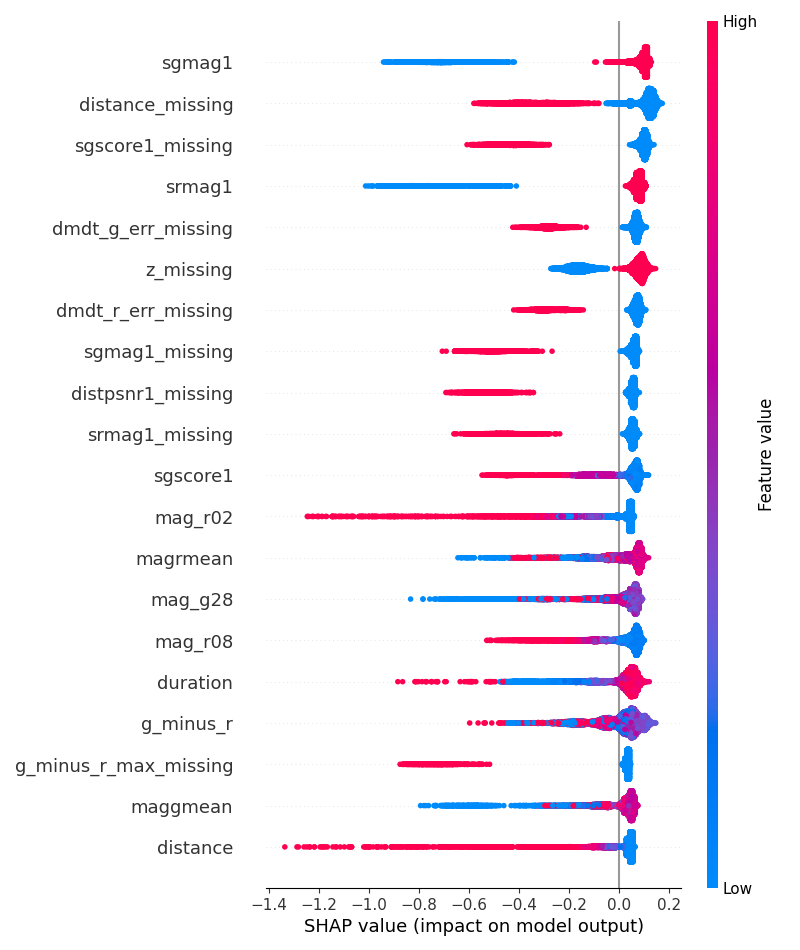

In [76]:
%matplotlib ipympl
# shap to see which features contribute to anomaly classification

# seems to pick out bright objects and objects that only have r band detections
import shap

# Train model
iso = IsolationForest(random_state=402)
iso.fit(X_scaled)

# Create SHAP explainer
explainer = shap.TreeExplainer(iso)

# Calculate SHAP values
shap_values = explainer.shap_values(X_scaled)
# summary plot
plt.close('all')
shap.summary_plot(shap_values, X_scaled)

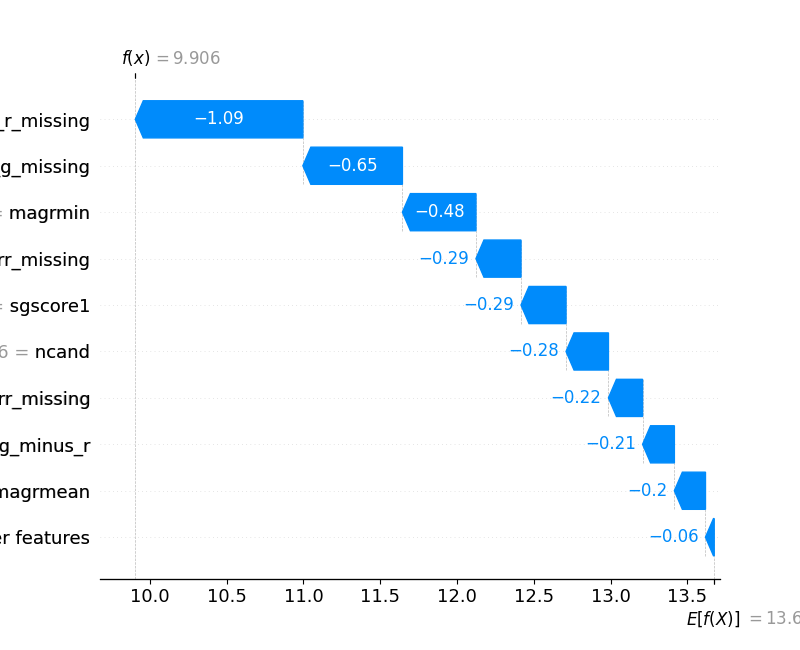

In [77]:
anomaly_idx = data[data["anomaly"] == -1].index[0]
plt.close('all')
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[anomaly_idx],
        base_values=explainer.expected_value,
        data=X_scaled.iloc[anomaly_idx]
    )
)

In [68]:
X_scaled

,glatmean,glonmean,gmag,dmdt_g,mag_g02,mag_g08,mag_g28,maggmax,maggmean,maggmin,...,dmdt_g_err_missing,dmdt_r_err_missing,z_missing,distance_missing,separationArcsec_missing,duration_missing,g_minus_r_max_missing,g_minus_r_mean_missing,anomaly_missing,anomaly_score_missing
0,-1.193825,1.056838,-0.678604,-0.011815,-0.170641,-0.482097,-1.555154,-1.346960,-2.534348,-2.137700,...,-0.525807,-0.466184,-1.314257,-0.572264,-0.144382,0.0,-0.230140,-0.230140,0.0,0.0
1,1.785746,-1.502631,-0.384150,-0.010212,-0.170640,-0.436294,-0.592110,-0.843446,-0.218058,0.061118,...,-0.525807,-0.466184,0.760886,-0.572264,-0.144382,0.0,-0.230140,-0.230140,0.0,0.0
2,0.283801,0.842331,-1.459438,-0.010641,-0.170645,-0.574559,-1.400422,-1.809996,-2.115677,-4.106464,...,1.901837,2.145075,0.760886,-0.572264,-0.144382,0.0,-0.230140,-0.230140,0.0,0.0
3,-0.077843,0.185994,0.911321,-0.010641,-0.170635,-0.276316,0.083548,0.602699,0.282065,0.151796,...,1.901837,2.145075,0.760886,-0.572264,-0.144382,0.0,-0.230140,-0.230140,0.0,0.0
4,1.619105,2.333315,-0.149338,-0.008150,1.017371,2.206769,1.435237,0.211571,0.176657,0.190252,...,-0.525807,-0.466184,0.760886,-0.572264,-0.144382,0.0,-0.230140,-0.230140,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,-1.320578,-0.313507,0.265648,-0.009000,-0.170638,-0.328674,-0.301371,0.505032,-2.351858,-2.491540,...,-0.525807,-0.466184,-1.314257,-0.572264,-0.144382,0.0,-0.230140,-0.230140,0.0,0.0
13316,0.738985,1.312741,-0.557322,-0.010641,-0.170641,-0.438880,-0.487962,-1.198236,-0.235250,0.334747,...,1.901837,-0.466184,0.760886,-0.572264,-0.144382,0.0,-0.230140,-0.230140,0.0,0.0
13317,0.793703,1.287454,-0.603709,-0.010641,-0.170641,-0.444459,-0.522523,-1.255119,-0.287531,0.292536,...,1.901837,-0.466184,0.760886,-0.572264,-0.144382,0.0,-0.230140,-0.230140,0.0,0.0
13318,-0.453697,-1.060270,-0.236736,-0.028437,-0.170643,-0.678885,-3.107034,-0.805116,-3.790221,-4.408764,...,-0.525807,-0.466184,0.760886,-0.572264,-0.144382,0.0,-0.230140,-0.230140,0.0,0.0


In [80]:
# top 100 anomalies based on anomaly score (the lower the more anomalous)
anoms_sorted=anoms.sort_values(by='anomaly_score')#[:10]
anoms_sorted[['objectId','tns_type','anomaly_score']][:100].to_csv('isolation_forest_top100.csv',index=False)

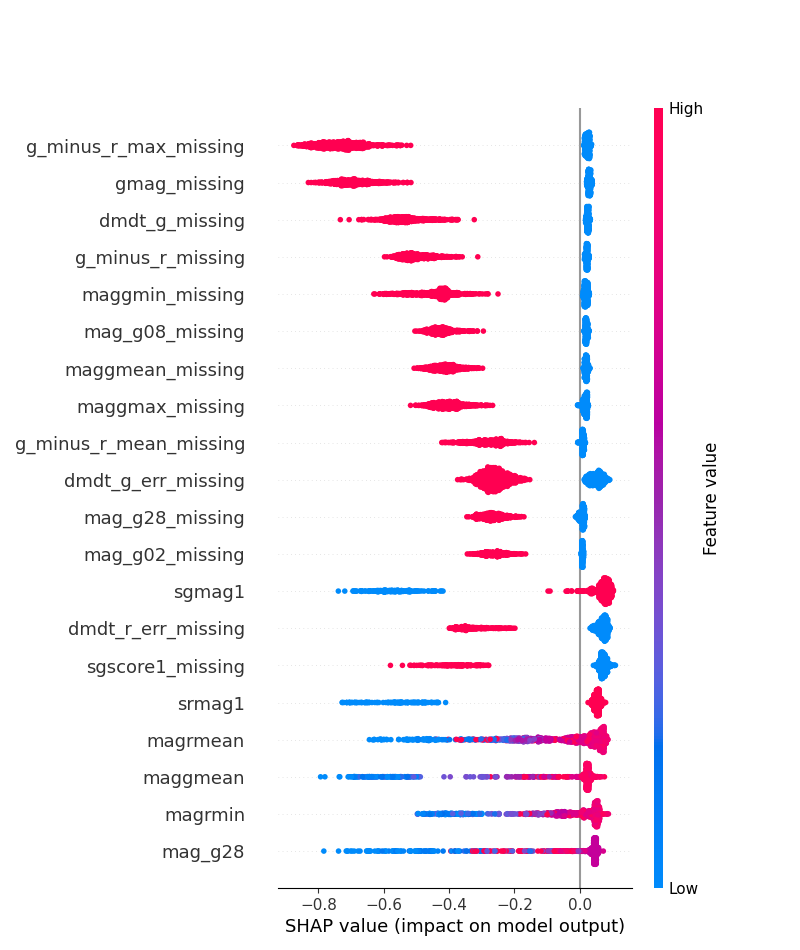

In [90]:
#shap_values = explainer.shap_values(X_scaled)
plt.close('all')
anomalies = X_scaled[data["anomaly"] == -1]
shap_values = explainer.shap_values(anomalies)
shap.summary_plot(shap_values, anomalies)
plt.savefig('shap_summary_anomalies.pdf')